In [110]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES

In [111]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "scatter_taxonomy"
output_folder.mkdir(exist_ok=True)


In [112]:
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()

# # EXCLUDE COLUMNS: 
# constant_columns = ["avg_degree", 
#                     "n_connected_components", 
#                     "density", 
#                     "density_bct", 
#                     "kernel_rank_phase_of_lambda_max"]
# df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

# cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
# len(cols_of_interest)

In [113]:
# dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]

In [114]:
# # Scatter plots. 
# n_cols = 8 
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 3)), sharex=True, sharey=True, dpi=200)
# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
#     im = ax.imshow(df_gnm_g.pivot(index="gamma", columns="eta", values=col), aspect="equal", origin="lower", cmap="viridis")

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:  
#         col = re.split(r'[,,_]+', col) # THIS IS OBV UGGLY: SEE ENERGY!! TODO Add comata again
#         # col = col.split("_")
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=4) 
    
#     # Add dots from the hcp dataset: TODO
#     # so: minima eta and gamma combinations, in the color of dict_with_all_datasets["hcp_schaefer_100_dataset"].groupby(["eta", "gamma"]).mean().reset_index().apply(lambda row: ax.scatter(x=row["eta"], y=row["gamma"], color="red", s=10), axis=1)

# # remove empty subplots
# for idx in range(len(cols_of_interest), n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# plt.tight_layout(pad=0.4)

## Now adding DeltaCon (or similar)

In [115]:
# # Get minima locations: GNM dataset

# df_indiv_distances = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/05_mst_animal_0_compared_with_hcp_schaefer_100/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_hcp_schaefer_100.csv") 
# # For each column, get the row index of the minimum value. FIRST OCCURANCE!! 
# minima_indices = df_indiv_distances.drop(columns=["eta", "gamma"]).idxmin()

# # Save eta, gamma, network_index, id, and filename of the minima in a new dataframe
# df_minima = df_indiv_distances.loc[minima_indices].reset_index(drop=True)
# print(df_indiv_distances) 

In [116]:
# df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()

# # EXCLUDE COLUMNS: -> Already done previously. 
# # constant_columns = ["avg_degree", "n_connected_components", "density", "density_bct", "kernel_rank_phase_of_lambda_max"]
# df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

# cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
# len(cols_of_interest)

In [117]:
# # Get all minimal deltacon values (and the corresponding eta-gamma values) 
# dict_with_all_datasets = {} 
# for dataset in dict_with_all_datasets.keys():
    
#     # As GNM already has energy and eta and gamma, only rename the "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)" column in the distance to "energy"
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].rename(columns={"MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": "energy"})
#         continue
    
#     # Get minima locations: GNM dataset
#     experiment_name = emp_dataset_and_experiment_pairs[dataset]
    
#     # if the following file does not exist, print a warning and skip this dataset
#     if not os.path.exists(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_delta_con_for_exp_{experiment_name}.csv"):
#         print(f"Warning: File not found for dataset {dataset}. Skipping this dataset.")
#         continue
    
#     df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_delta_con_for_exp_{experiment_name}.csv") 
#     # For each column, get the row index of the minimum value. FIRST OCCURANCE!! 
#     minima_indices = df_indiv_distances.drop(columns=["eta", "gamma"]).idxmin()

#     # Save eta, gamma, network_index, id, and filename of the minima in a new dataframe
#     df_minima = df_indiv_distances.loc[minima_indices].reset_index(drop=True)
#     print(df_indiv_distances) 
    
#     print(f"{dataset}: {len(dict_with_all_datasets[dataset].columns)} columns")
#     # Find minimum DeltaCon locations for each subject
#     df_min_locations = pd.DataFrame(columns=["DeltaCon_subject", "eta", "gamma", "id"])
#     deltacon_cols = [col for col in df_indiv_distances.columns if col.startswith('DeltaCon_subject_')]

#     # Get the set of "clean" base names that already exist (no _x or _y suffix)
#     base_cols = {col for col in deltacon_cols if not col.endswith('_x') and not col.endswith('_y')}

#     for deltacon_col in deltacon_cols:
#         # Skip _y columns always
#         if deltacon_col.endswith('_y'):
#             continue
        
#         # Skip _x columns if the base column already exists
#         if deltacon_col.endswith('_x'):
#             base_name = deltacon_col[:-2]  # strip "_x"
#             if base_name in base_cols:
#                 continue  # base column exists, so ignore this duplicate
#             else:
#                 # Base doesn't exist, so rename and use it
#                 df_indiv_distances.rename(columns={deltacon_col: base_name}, inplace=True)
#                 deltacon_col = base_name

#         min_idx = df_indiv_distances[deltacon_col].idxmin()
        
#         # Warning, if df_indiv_distances does not exist
#         if df_indiv_distances is None:
#             print(f"Warning: df_indiv_distances does not exist for {dataset}.")
#             continue

#         df_min_locations = pd.concat([df_min_locations, pd.DataFrame({"DeltaCon_subject": deltacon_col,
#                                             "eta": df_indiv_distances.loc[min_idx, 'eta'],
#                                             "gamma": df_indiv_distances.loc[min_idx, 'gamma'],
#                                             "id": df_indiv_distances.loc[min_idx, 'id'],
#                                             "min_value": df_indiv_distances.loc[min_idx, deltacon_col]},
#                                             index=[0])], ignore_index=True)


#         # Merge by index
#         df_merged = pd.merge(df_min_locations, dict_with_all_datasets[dataset], left_index=True, right_index=True)
#         dict_with_all_datasets[dataset] = df_merged

In [118]:
# # TODO: ADD THEM FOR ALL DATASETS! 


# # Get all minimal Energies (and the corresponding eta and gamma) for each subject, and merge them with the gnm data.


# dict_with_all_datasets = {} 
# for dataset in dict_with_all_datasets.keys():
    
#     # As GNM already has energy and eta and gamma, only rename the "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)" column in the distance to "energy"
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         dict_with_all_datasets[dataset] = dict_with_all_datasets[dataset].rename(columns={"MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": "energy"})
#         continue

#     # Now, for the empirical datasets, get the individual energy minima and merge them. 
#     experiment_name = emp_dataset_and_experiment_pairs[dataset]
#     # if they exist...
#     if not os.path.exists(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_energy_for_exp_{experiment_name}.csv"):
#         print(f"File not found: {dataset}/{experiment_name}")
#         continue

#     df_indiv_distances = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset}/{experiment_name}/summary_indiv_energy_for_exp_{experiment_name}.csv")

#     print(f"{dataset}: {len(dict_with_all_datasets[dataset].columns)} columns")
    
#     # Find minimum MaxCrit locations for each subject
#     df_min_locations = pd.DataFrame(columns=["energy", "eta", "gamma", "id"])
#     maxcrit_cols = [col for col in df_indiv_distances.columns if col.startswith('MaxCrit_subject_')]
#     for maxcrit_col in maxcrit_cols:

#         # if "_y" in maxcrit_col:
#         #     continue  # Skip columns that are not individual MaxCrit measures
#         # if "_x" in maxcrit_col:
#         #     # remove that part to get the original subject name.
#         #     maxcrit_col = maxcrit_col.split("_x")[0]
#         #     # rename that column in df_indiv_distances to the original name, so that we can use it later for merging with the gnm data.
#         #     df_indiv_distances.rename(columns={maxcrit_col + "_x": maxcrit_col}, inplace=True)

#         min_idx = df_indiv_distances[maxcrit_col].idxmin()
#         df_min_locations = pd.concat([df_min_locations, pd.DataFrame({
#                                             "energy": df_indiv_distances.loc[min_idx, maxcrit_col], # maxcrit_col, 
#                                             "eta": df_indiv_distances.loc[min_idx, 'eta'], 
#                                             "gamma": df_indiv_distances.loc[min_idx, 'gamma'], 
#                                             "id": df_indiv_distances.loc[min_idx, 'id'], 
#                                             # "min_value": df_indiv_distances.loc[min_idx, maxcrit_col]
#                                             },                   
#                                             index=[0])], ignore_index=True)


#         # Merge by index
#         df_merged = pd.merge(df_min_locations, dict_with_all_datasets[dataset], left_index=True, right_index=True)
#         dict_with_all_datasets[dataset] = df_merged

In [119]:
# # I HOPE THIS WORKS (and does not mix up information): Merge by index
# dict_with_all_datasets = {} 
# for dataset in dict_with_all_datasets.keys():
#     df_merged = pd.merge(df_min_locations, dict_with_all_datasets[dataset], left_index=True, right_index=True)
#     dict_with_all_datasets[dataset] = df_merged

In [120]:
# x_max = pivot_data.columns.max()
# y_max = pivot_data.index.max()
# x_min = pivot_data.columns.min()
# y_min = np.floor(pivot_data.index.min()*10)/10
# print(f"x range: {x_min} to {x_max}")
# print(f"y range: {y_min} to {y_max}")

In [121]:
# def scale_to_im_HARDCODED_x(x):
#     return (x + 8) / (3 + 8) * 50 # size of im

# def scale_to_im_HARDCODED_y(x):
#     return (x + 1) / (1 + 0.1) * 50 # size of im

In [122]:
# im.get_size() # (50, 50)

In [123]:
# plt.figure(figsize=(6, 5), dpi=200)
# # Plot individual points
# col="avg_clustering"
# for dataset in dict_with_all_datasets.keys():

#     # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         continue

#     df_merged = dict_with_all_merged_dataasets[dataset]  
#     print(dataset, df_merged.columns)
#     print(len(df_merged))
#     if col in df_merged.columns:
        
#         if "eta" not in df_merged.columns or "gamma" not in df_merged.columns:
#             print(f"Warning: 'eta' or 'gamma' column not found in dataset {dataset}. Skipping scatter points for this dataset.")
#             continue
        
#         plt.scatter(df_merged["eta"], df_merged['gamma'],
#                     c=df_merged[col],
#                     edgecolor="black",
#                     linewidth=0.25, s=5)
# plt.show()

In [124]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
#     # Create the heatmap
#     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

#     # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
#     x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
#     y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

#     im = ax.imshow(pivot_data, 
#                    extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                    aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")

#     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         df_merged = dict_with_all_datasets[dataset]
#         if col in df_merged.columns:
            
#             # Skip datasets that do not have eta and gamma columns, as we cannot plot them in the scatter plot.
#             if "eta" not in df_merged.columns or "gamma" not in df_merged.columns:
#                 print(f"Warning: 'eta' or 'gamma' column not found in dataset {dataset}. Skipping scatter points for this dataset.")
#                 continue
            
#             ax.scatter(df_merged["eta"], df_merged['gamma'],
#                 #    c=df_merged[col],
#                        c=COLOR_SCHEME[dataset],
#                        edgecolor="black",
#                        label=dataset,
#                        linewidth=0.25, s=5)

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left')
    
#     cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=4) 
    
#     if idx >= 2: 
#         break

# # remove empty subplots
# for idx in range(idx+1, n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# plt.tight_layout(pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [125]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# # n_cols = 8
# # n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# # fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)
# col = cols_of_interest[0] # energy


# plt.figure(figsize=viz.cm_to_inch((8,6)))
# # for idx, col in enumerate(cols_of_interest):

# # Create the heatmap
# pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

# # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
# x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
# y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

# plt.imshow(pivot_data, 
#                 extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                 aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")

# # Plot individual points
# for dataset in dict_with_all_datasets.keys():

#     # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#     if dataset == "hcp_schaefer_100_dataset_gnm":
#         continue

#     df_merged = dict_with_all_datasets[dataset]
#     if col in df_merged.columns:
    
#         # Skip datasets that do not have eta and gamma columns, as we cannot plot them in the scatter plot.
#         if "eta" not in df_merged.columns or "gamma" not in df_merged.columns:
#             print(f"Warning: 'eta' or 'gamma' column not found in dataset {dataset}. Skipping scatter points for this dataset.")
#             continue
        
#         plt.scatter(df_merged["eta"], df_merged['gamma'],
#             #    c=df_merged[col],
#                     c=COLOR_SCHEME[dataset],
#                     edgecolor="black",
#                     label=dataset,
#                     linewidth=0.25, s=20)

# # if the title is too long (define this), then split it into two lines at the last underscore
# if len(col) > 20:
#     col = re.split(r'[,,_]+', col)
#     len_col = len(col)
#     col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
# plt.title(col) #  fontsize=6)

# plt.xticks([])
# plt.yticks([])

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# cbar.ax.tick_params(labelsize=4) 
    
# plt.tight_layout(pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [126]:

# # drop row 95
# if 95 in dict_with_all_datasets["suarez_MaMI_dataset"].index:
#     dict_with_all_datasets["suarez_MaMI_dataset"] = dict_with_all_datasets["suarez_MaMI_dataset"].drop(index=95)

# dict_with_all_datasets["suarez_MaMI_dataset"]

# TAXONOMIES 

In [127]:
# # Taxonomies 
# info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
# info_mami

In [128]:
# # join dict_with_all_datasets["suarez_MaMI_dataset"] and info_mami by index 
# df_merged_mami = pd.merge(dict_with_all_datasets["suarez_MaMI_dataset"], info_mami, left_index=True, right_index=True)
# df_merged_mami

In [129]:
# # df_merged_mami["order"] to color the points in the scatter plot. But: Order entries are strings rn...
# df_merged_mami["order_color"] = df_merged_mami["order"].astype("category").cat.codes
# df_merged_mami["phylogenetic_group_color"] = df_merged_mami["phylogenetic_group"].astype("category").cat.codes
# df_merged_mami[["order_color", "phylogenetic_group_color"]]


In [130]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
#     # Create the heatmap
#     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

#     # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
#     x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
#     y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

#     im = ax.imshow(pivot_data, 
#                    extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                    aspect="auto", origin="lower", cmap="viridis")
    
#     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         # df_merged = dict_with_all_datasets[dataset]
#         # if col in df_merged.columns:
#         #     ax.scatter(df_merged["eta"], df_merged['gamma'],
#         #                c=df_merged[col],
#         #                edgecolor="black",
#         #                linewidth=0.25, s=5)
        
#         ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
#             c=df_merged_mami["order_color"],
#             # label=df_merged_mami["order"],
#             edgecolor="black",
#             linewidth=0.25, s=5, cmap="RdYlGn_r")

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # Make legend with "order_color" colors and "order" labels
#     # handles, labels = ax.get_legend_handles_labels()
#     # by_label = dict(zip(list(set(labels)), list(set(handles))))
#     # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
#     # Here we create a legend: # TODO: FIX???
#     # we'll plot empty lists with the desired size and label
#     for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
#         ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
#                     label=str(name))
#     ax.legend(fontsize=2, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

#     cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=4) 
    
#     break
    
#     # if idx >= 2: 
#     #     break
    


# # remove empty subplots
# for idx in range(idx+1, n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# # title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

# plt.tight_layout(pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [131]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 2
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 4)), sharex=True, sharey=True, dpi=200)

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
#     # Create the heatmap
#     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

#     # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
#     x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
#     y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

#     im = ax.imshow(pivot_data, 
#                    extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                    aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")
    
#     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         # df_merged = dict_with_all_datasets[dataset]
#         # if col in df_merged.columns:
#         #     ax.scatter(df_merged["eta"], df_merged['gamma'],
#         #                c=df_merged[col],
#         #                edgecolor="black",
#         #                linewidth=0.25, s=5)
        
#         ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
#             c=df_merged_mami["order_color"],
#             # label=df_merged_mami["order"],
#             edgecolor="black",
#             linewidth=0.25, s=5, cmap="RdYlGn_r")

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # Make legend with "order_color" colors and "order" labels
#     # handles, labels = ax.get_legend_handles_labels()
#     # by_label = dict(zip(list(set(labels)), list(set(handles))))
#     # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
#     # Here we create a legend: # TODO: FIX???
#     # we'll plot empty lists with the desired size and label
#     for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
#         ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
#                     label=str(name))
#     ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

#     # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     # cbar.ax.tick_params(labelsize=4) 
    
#     break
    
#     # if idx >= 2: 
#     #     break
    


# # remove empty subplots
# for idx in range(idx+1, n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# # title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

# plt.tight_layout() # pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [132]:
# df_merged_mami

In [133]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 2
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 4)), sharex=True, sharey=True, dpi=200)

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
#     # Create the heatmap
#     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

#     # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
#     x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
#     y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

#     im = ax.imshow(pivot_data, 
#                    extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                    aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")
    
#     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         # df_merged = dict_with_all_datasets[dataset]
#         # if col in df_merged.columns:
#         #     ax.scatter(df_merged["eta"], df_merged['gamma'],
#         #                c=df_merged[col],
#         #                edgecolor="black",
#         #                linewidth=0.25, s=5)
        
#         ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
#             c=df_merged_mami["order_color"],
#             # label=df_merged_mami["order"],
#             edgecolor="black",
#             linewidth=0.25, s=5, cmap="RdYlGn_r")

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # Make legend with "order_color" colors and "order" labels
#     # handles, labels = ax.get_legend_handles_labels()
#     # by_label = dict(zip(list(set(labels)), list(set(handles))))
#     # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
#     # Here we create a legend: # TODO: FIX???
#     # we'll plot empty lists with the desired size and label
#     for color, name in zip(list(set(df_merged_mami["phylogenetic_group_color"])), list(set(df_merged_mami["phylogenetic_group"]))):
#         ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
#                     label=str(name))
#     ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

#     # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     # cbar.ax.tick_params(labelsize=4) 
    
#     break
    
#     # if idx >= 2: 
#     #     break
    


# # remove empty subplots
# for idx in range(idx+1, n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# # title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

# plt.tight_layout() # pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [134]:
# # Get the metric values at these minimum locations for coloring
# # We'll use the same metric as shown in each subplot
# # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 2
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
#     # Create the heatmap
#     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

#     # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
#     x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
#     y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

#     im = ax.imshow(pivot_data, 
#                    extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
#                    aspect="auto", origin="lower", cmap="viridis")
    
#     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         # df_merged = dict_with_all_datasets[dataset]
#         # if col in df_merged.columns:
#         #     ax.scatter(df_merged["eta"], df_merged['gamma'],
#         #                c=df_merged[col],
#         #                edgecolor="black",
#         #                linewidth=0.25, s=5)
        
#         ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
#             c=df_merged_mami["order_color"],
#             # label=df_merged_mami["order"],
#             edgecolor="black",
#             linewidth=0.25, s=5, cmap="RdYlGn_r")

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # Make legend with "order_color" colors and "order" labels
#     # handles, labels = ax.get_legend_handles_labels()
#     # by_label = dict(zip(list(set(labels)), list(set(handles))))
#     # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
#     # Here we create a legend: # TODO: FIX???
#     # we'll plot empty lists with the desired size and label
#     for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
#         ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
#                     label=str(name))
#     ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

#     # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     # cbar.ax.tick_params(labelsize=4) 
    
#     break
    
#     # if idx >= 2: 
#     #     break
    


# # remove empty subplots
# for idx in range(idx+1, n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# # title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

# plt.tight_layout() # pad=0.4)

# # plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [135]:
# # # Get the metric values at these minimum locations for coloring
# # # We'll use the same metric as shown in each subplot
# # # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), dpi=200) #  sharex=True, sharey=True, 

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
# #     # Create the heatmap
# #     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)
#     ax.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
#                color="gray", linewidth=0, s=5, alpha=0.2) # edgecolor="black")


# #     # Plot individual points
#     for dataset in dict_with_all_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         df_merged = dict_with_all_datasets[dataset]

#         if col in df_merged.columns:
#             ax.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
#                        df_merged[col],
#                     #    c=df_merged[col],
#                        edgecolor="black",
#                        color=COLOR_SCHEME[dataset],
#                        linewidth=0.25, s=5)

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     # ax.set_xticks([])
#     # ax.set_yticks([])
    
#     # Change the fontsize of the ax ticks to 6
#     ax.tick_params(axis='both', labelsize=6)
#     # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     # cbar.ax.tick_params(labelsize=4) 
    
# #     # if idx >= 2: 
# #     #     break

# # remove empty subplots
# for idx in range(len(cols_of_interest), n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# plt.tight_layout(pad=0.4)

In [136]:
# # save dict_with_all_datasets: 
# with open(output_folder / "all_datasets_merged_with_minima_locations_deltacon.pkl", "wb") as f:
#     pickle.dump(dict_with_all_datasets, f)

In [137]:
# dict_with_all_datasets["suarez_MaMI_dataset"]

# Trade-offs etc 

In [138]:
cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]

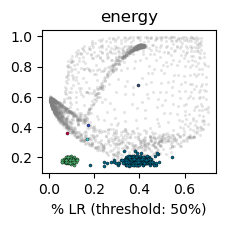

Save path:  /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/scatter_taxonomy


In [139]:
for idx, col in enumerate(cols_of_interest):
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

    plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
               color="gray", linewidth=0, s=5, alpha=0.2) 

    if len(col) > 20:
        col_for_title = re.split(r'[,,_]+', col)
        len_col = len(col_for_title)
        col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

    if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
        col = "min_value"
        col_for_title = "Distance Measure"

    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]

        if col in df_merged.columns:
            plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                       df_merged[col],
                    #    c = df_merged[col],
                       edgecolor="black",
                       color=COLOR_SCHEME[dataset],
                       linewidth=0.25, s=5)
    
    plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.title(col) # , fontsize=6)
    
    plt.tight_layout()
    plt.savefig(output_folder / f"fig_{idx}_{col}_scatter.png", dpi=200)
    if idx == 0:
        plt.show()
    else: 
        plt.close()

print("Save path: ", output_folder)

In [140]:
df_gnm_g

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,-8.0,-0.100000,0.931,0.015520,68.912802,34111.837109,2.237475,35.3,74.740613,8.379198,...,221.65,0.44869,0.485927,0.923368,0.487,0.4983,2.666178,0.133791,0.812038,0.468
1,-8.0,-0.077551,0.934,0.015567,68.775390,34043.817578,2.238646,37.1,69.670481,8.407290,...,221.60,0.45505,0.486249,0.935839,0.491,0.4969,2.440664,0.123242,0.711938,0.440
2,-8.0,-0.055102,0.939,0.015572,68.838924,34075.267188,2.234909,39.2,72.679114,8.320874,...,221.55,0.45774,0.486455,0.940996,0.493,0.4981,3.068431,0.152928,0.871220,0.638
3,-8.0,-0.032653,0.933,0.015549,68.495776,33905.408984,2.235697,37.8,67.709734,8.379292,...,221.35,0.45647,0.486966,0.937376,0.493,0.4985,3.019175,0.153873,0.870720,0.638
4,-8.0,-0.010204,0.936,0.015602,69.017478,34163.651563,2.235172,35.9,69.975212,8.336929,...,222.90,0.45472,0.486586,0.934556,0.487,0.4976,2.993023,0.151654,0.880869,0.610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3.0,0.910204,0.326,0.008264,71.699420,35491.212891,5.133980,128.4,83.668096,6.750237,...,99.00,0.35920,0.362585,0.992445,0.339,0.3015,0.019267,0.000615,0.330887,0.478
2496,3.0,0.932653,0.317,0.008387,73.086583,36177.858594,4.907172,126.9,84.562829,6.856519,...,99.00,0.35498,0.366310,0.977248,0.344,0.3065,0.022783,0.000728,0.341379,0.460
2497,3.0,0.955102,0.338,0.008264,73.510998,36387.944141,5.132020,126.7,84.072289,6.675188,...,99.00,0.35127,0.357857,0.987608,0.333,0.2983,0.021020,0.000681,0.392371,0.452
2498,3.0,0.977551,0.313,0.008357,73.208488,36238.201172,4.634364,123.8,85.426667,6.802856,...,99.00,0.34037,0.369171,0.929514,0.319,0.3097,0.033159,0.001035,0.414867,0.426


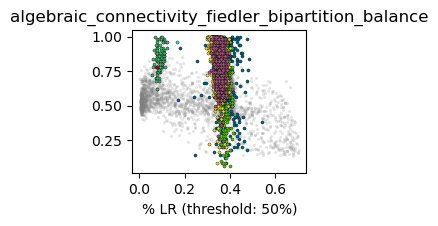

In [141]:

fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5)

plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/1431489389.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


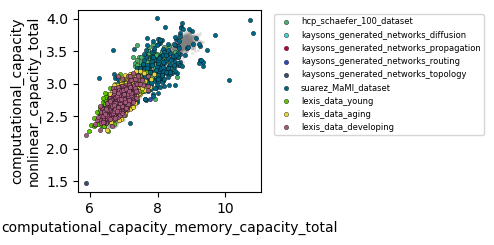

In [142]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/745601709.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


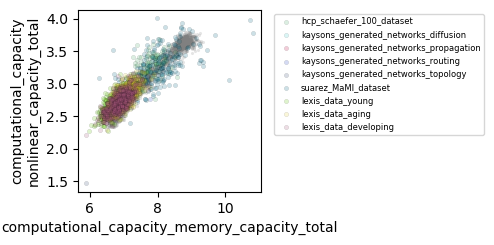

In [143]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    alpha=0.2, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/3393266128.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


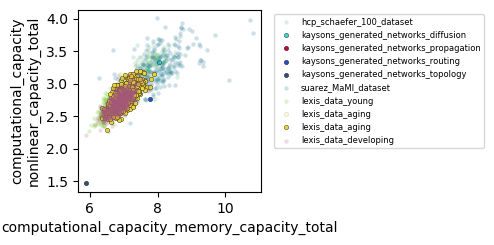

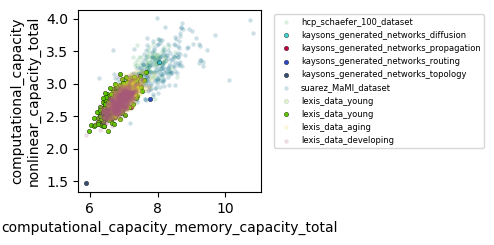

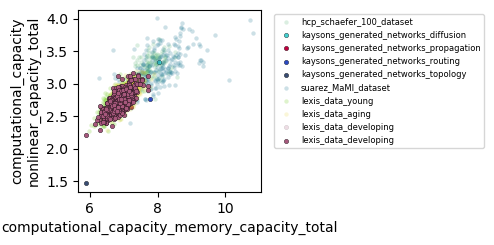

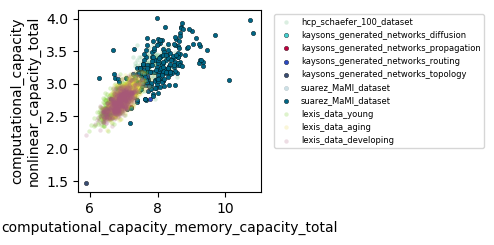

In [144]:


x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
# plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
#             color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset_to_highlight in ["aging", "young", "developing", "MaMI"]: # , "kayson"
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    
    
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]

        if y_col in df_merged.columns:
            plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                        df_merged[y_col],
                    #    c = df_merged[col],
                        edgecolor="black",
                        color=COLOR_SCHEME[dataset],
                        label=dataset,
                        linewidth=0.25 if ("kayson" in dataset) or (dataset_to_highlight in dataset) else 0, 
                        alpha=1 if "kayson" in dataset else 0.2,
                        s=10
                        )
            
        # Plot again over it to highlight the dataset of interest (e.g., "aging" or "kayson")
        if dataset_to_highlight in dataset:
            plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                            df_merged[y_col],
                        #    c = df_merged[col],
                            edgecolor="black",
                            color=COLOR_SCHEME[dataset],
                            label=dataset,
                            linewidth=0.25, #  if ("kayson" in dataset) or (dataset_to_highlight in dataset) else 0, 
                            alpha=1, #  if "kayson" in dataset else 0.2,
                            s=10
                            )
    # plt.xscale("log")
    plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.ylabel(col_for_title) # , fontsize=6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.tight_layout()
    plt.show()


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/597307819.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


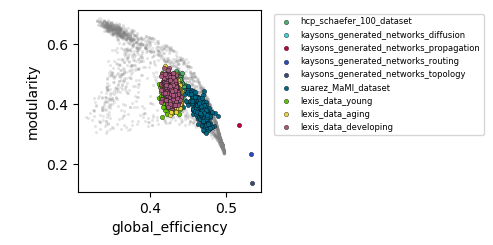

In [145]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "global_efficiency" # computational_capacity_memory_capacity_total"
y_col = "modularity" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/464047416.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


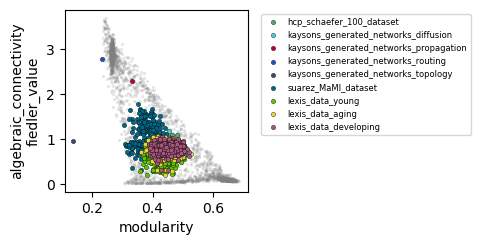

In [146]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "modularity" # computational_capacity_memory_capacity_total"
y_col = "algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/3566442827.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # TODO: INCLUDE IN DOCS


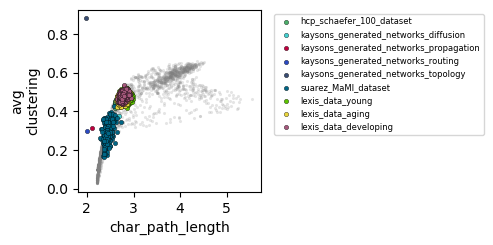

In [147]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "char_path_length" # modularity" # computational_capacity_memory_capacity_total"
y_col = "avg_clustering" # algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black", 
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout() # TODO: INCLUDE IN DOCS

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/3825350680.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


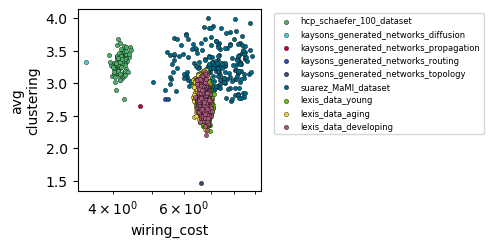

In [148]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
# plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
#             color="gray", linewidth=0, s=5, alpha=0.2) 

# if len(col) > 20:
#     col_for_title = re.split(r'[,,_]+', y_col)
#     len_col = len(col_for_title)
#     col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

# if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
#     col = "min_value"
#     col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/2248280260.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


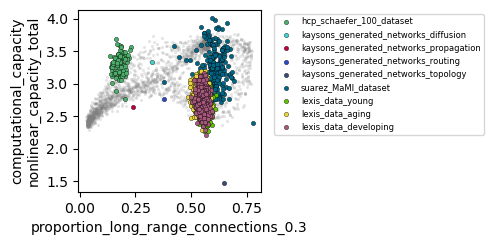

In [149]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "proportion_long_range_connections_0.3" # wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/1431489389.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


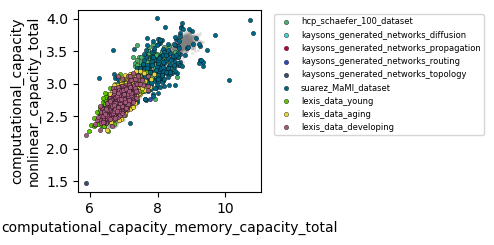

In [150]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/2598459210.py:14: SyntaxWarning: invalid escape sequence '\%'
  x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"


hcp_schaefer_100_dataset_gnm 175
hcp_schaefer_100_dataset 172
kaysons_generated_networks_diffusion 174
kaysons_generated_networks_propagation 174
kaysons_generated_networks_routing 174
kaysons_generated_networks_topology 169
suarez_MaMI_dataset 174
lexis_data_young 170
lexis_data_aging 170
lexis_data_developing 170
hcp_schaefer_100_dataset_gnm 175
hcp_schaefer_100_dataset 172
kaysons_generated_networks_diffusion 174
kaysons_generated_networks_propagation 174
kaysons_generated_networks_routing 174
kaysons_generated_networks_topology 169
suarez_MaMI_dataset 174
lexis_data_young 170
lexis_data_aging 170
lexis_data_developing 170
hcp_schaefer_100_dataset_gnm 175
hcp_schaefer_100_dataset 172
kaysons_generated_networks_diffusion 174
kaysons_generated_networks_propagation 174
kaysons_generated_networks_routing 174
kaysons_generated_networks_topology 169
suarez_MaMI_dataset 174
lexis_data_young 170
lexis_data_aging 170
lexis_data_developing 170
hcp_schaefer_100_dataset_gnm 175
hcp_schaefer_100

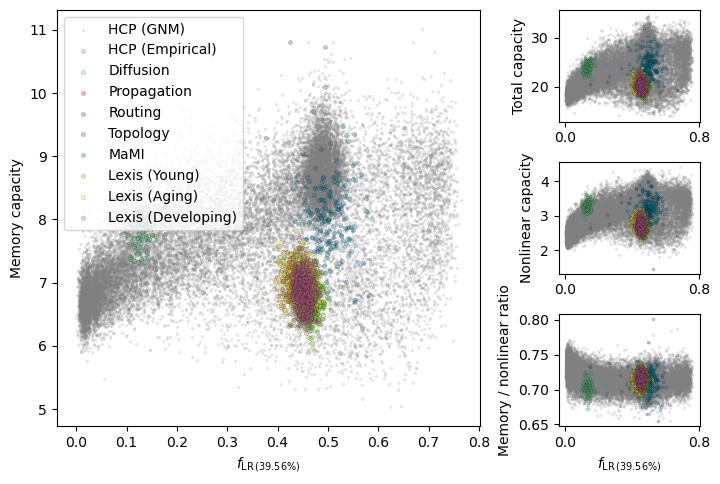

In [151]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
output_folder = output_folder / "trade_off_scatters"
output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset, df_merged in dict_with_all_datasets.items():
        print(dataset, len(df_merged.columns))
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color="gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 5,
                alpha=0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections.pdf", bbox_inches="tight", dpi=300)
plt.show()

hcp_schaefer_100_dataset_gnm 175
hcp_schaefer_100_dataset 172
kaysons_generated_networks_diffusion 174
kaysons_generated_networks_propagation 174
kaysons_generated_networks_routing 174
kaysons_generated_networks_topology 169
suarez_MaMI_dataset 174
lexis_data_young 170
lexis_data_aging 170
lexis_data_developing 170
hcp_schaefer_100_dataset_gnm 175


<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_65413/1638650652.py:14: SyntaxWarning: invalid escape sequence '\%'
  x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"


KeyError: 'targeted_attack_robustness_rob_total_capacity'

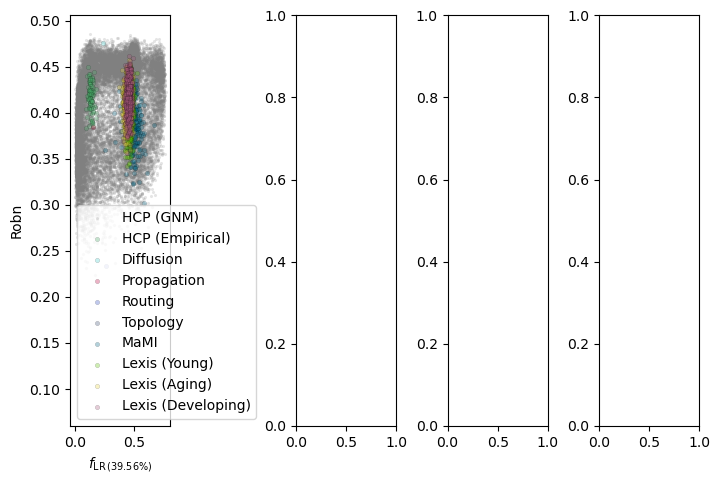

In [152]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
output_folder = output_folder / "trade_off_scatters"
output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("targeted_attack_robustness_rob_targeted_auc",    "Robn"),
    "B": ("targeted_attack_robustness_rob_total_capacity",           "Total capacity"),
    "C": ("targeted_attack_robustness_rob_nonlinear_capacity", "Nonlinear capacity"),
    "D": ("targeted_attack_robustness_rob_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    ABCD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset, df_merged in dict_with_all_datasets.items():
        print(dataset, len(df_merged.columns))
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color="gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 5,
                alpha=0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]

,DeltaCon_subject,eta_x,gamma_x,id,min_value,eta_y,gamma_y,energy,avg_communicability,avg_edge_distance,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,DeltaCon_subject_0,2.551020,0.191837,8,6.335841,1.204082,0.304082,0.320000,0.011247,76.077667,...,104.0,0.3978,0.46037,0.864088,0.44,0.462,0.228483,0.008238,0.689275,0.16
1,DeltaCon_subject_1,2.551020,0.191837,8,6.813749,-4.857143,0.663265,0.880000,0.014904,63.799976,...,198.0,0.4446,0.48827,0.910562,0.48,0.500,2.884382,0.133069,0.946072,0.78
2,DeltaCon_subject_2,0.306122,0.124490,5,6.605616,-5.979592,0.124490,0.940000,0.015729,70.102951,...,228.5,0.4557,0.48724,0.935268,0.49,0.498,2.883610,0.146973,0.906313,0.56
3,DeltaCon_subject_3,2.551020,0.214286,9,6.802691,0.530612,0.146939,0.670000,0.013722,69.063416,...,135.5,0.4182,0.48623,0.860087,0.49,0.493,1.511857,0.061605,0.901723,0.26
4,DeltaCon_subject_4,-1.714286,-0.010204,8,7.333884,-3.959184,0.932653,0.438384,0.012760,45.163860,...,137.5,0.4322,0.48371,0.893511,0.48,0.497,1.735451,0.073960,0.859572,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,DeltaCon_subject_220,-0.367347,-0.055102,7,7.073544,-0.816326,0.169388,0.510000,0.013865,50.995834,...,120.0,0.4280,0.47935,0.892876,0.45,0.486,0.941239,0.044186,0.596935,0.18
221,DeltaCon_subject_221,-3.061224,-0.055102,7,7.412341,-5.979592,-0.032653,0.950000,0.015328,68.365929,...,217.0,0.4536,0.48563,0.934044,0.48,0.499,2.932624,0.148634,0.983869,0.62
222,DeltaCon_subject_222,-5.081633,0.214286,2,7.446855,-2.163265,-0.077551,0.990000,0.015682,54.644249,...,245.5,0.4591,0.48800,0.940779,0.50,0.500,3.204409,0.165842,0.987507,0.66
223,DeltaCon_subject_223,-5.081633,-0.032653,9,6.937792,-8.000000,0.753061,0.950000,0.015581,68.903725,...,216.5,0.4401,0.48909,0.899834,0.48,0.500,2.599015,0.134476,0.763556,0.44


In [ ]:
from utils import get_colorchannels_from_eta_gamma

combined_colors = get_colorchannels_from_eta_gamma(dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"], "eta", "gamma") 

hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
lexis_data_aging 168 687
lexis_data_developing 168 629
hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
lexis_data_aging 168 687
lexis_data_developing 168 629
hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
le

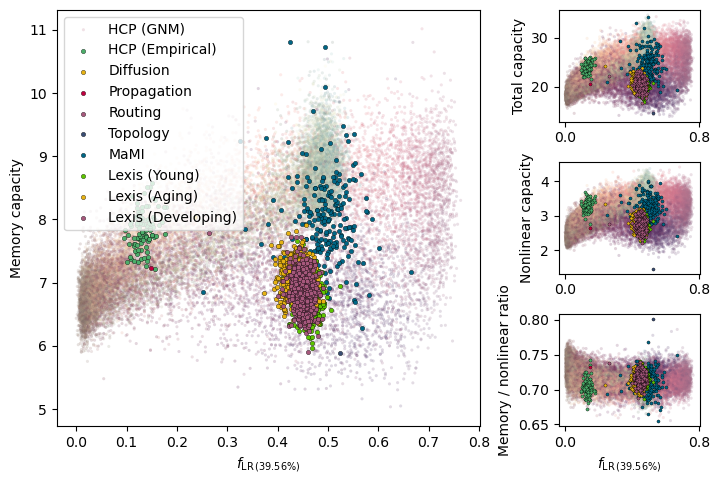

In [ ]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
output_folder = output_folder / "trade_off_scatters"
output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset, df_merged in dict_with_all_datasets.items():
        print(dataset, len(df_merged.columns), len(df_merged))
        
        # Skip Lexis datasets
        # if "lexi" in dataset:
        #     print("Found lexi dataset, skipping for now.")
        #     continue
        
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            len(df_merged)
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors, # "gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 5,
                alpha=1, # 0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections_mami_and_hcp.pdf", bbox_inches="tight", dpi=300)
plt.show()

hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
lexis_data_aging 168 687
lexis_data_developing 168 629
hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
lexis_data_aging 168 687
lexis_data_developing 168 629
hcp_schaefer_100_dataset_gnm 173 25000
hcp_schaefer_100_dataset 172 100
kaysons_generated_networks_diffusion 172 1
kaysons_generated_networks_propagation 172 1
kaysons_generated_networks_routing 172 1
kaysons_generated_networks_topology 167 2
suarez_MaMI_dataset 172 224
lexis_data_young 168 703
le

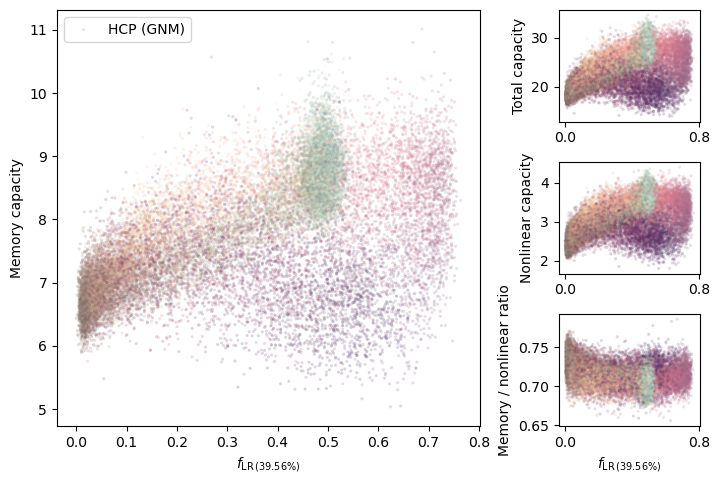

In [ ]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
output_folder = output_folder / "trade_off_scatters"
output_folder.mkdir(exist_ok=True)

# x_col = "wiring_cost" # 
x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset, df_merged in dict_with_all_datasets.items():
        print(dataset, len(df_merged.columns), len(df_merged))
        
        # Skip Lexis datasets
        # if "lexi" in dataset:
        #     print("Found lexi dataset, skipping for now.")
        #     continue
        
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # pass
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            len(df_merged)
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors, # "gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        # #     continue
        else: 
            pass
            # if x_col not in df_merged.columns or y_col not in df_merged.columns:
            #     print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
            #     continue

            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=1, # 0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections_mami_and_hcp.pdf", bbox_inches="tight", dpi=300)
plt.show()

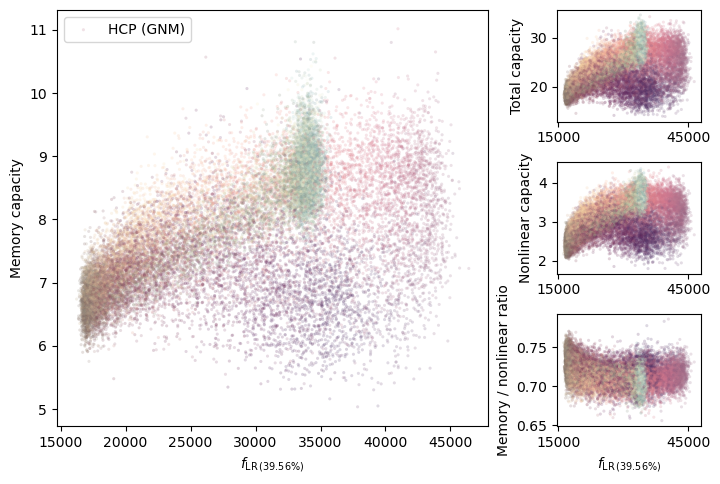

# Further trade-off experiments

Skipping lexis_data_young because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_aging because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_developing because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_young because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_aging because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_developing because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_young because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_aging because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_developing because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_young because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_aging because it's a Lexis dataset and INCLUDE_LEXIS is False.
Skipping lexis_data_developing because it's a Lexis dataset and INCLUDE_

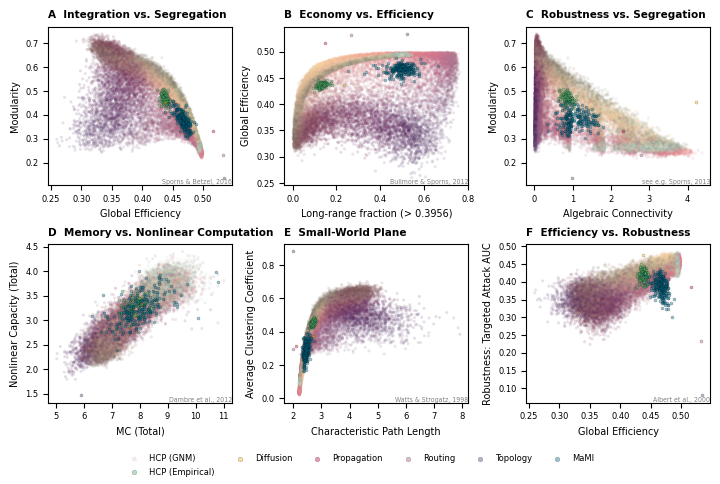

In [ ]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────

trade_off_panels = {
    "A": {
        "x": "global_efficiency",
        "y": "modularity",
        "title": "Integration vs. Segregation",
        "ref": "Sporns & Betzel, 2016",
    },
    "B": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "global_efficiency",
        "title": "Economy vs. Efficiency",
        "ref": "Bullmore & Sporns, 2012",
    },
    "C": {
        "x": "algebraic_connectivity_nx",
        "y": "modularity",
        "title": "Robustness vs. Segregation",
        "ref": "see e.g. Sporns, 2013",
    },
    "D": {
        "x": "computational_capacity_memory_capacity_total",
        "y": "computational_capacity_nonlinear_capacity_total",
        "title": "Memory vs. Nonlinear Computation",
        "ref": "Dambre et al., 2012",
    },
    "E": {
        "x": "char_path_length",
        "y": "avg_clustering",
        "title": "Small-World Plane",
        "ref": "Watts & Strogatz, 1998",
    },
    "F": {
        "x": "global_efficiency",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Efficiency vs. Robustness",
        "ref": "Albert et al., 2000",
    },
}

INCLUDE_LEXIS = False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12)), layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset, df_merged in dict_with_all_datasets.items():
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=7)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=7)
    ax.tick_params(labelsize=6)

    # Panel letter + title
    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7.5, fontweight="bold", loc="left")

    # Reference annotation (bottom-right, small)
    ax.annotate(
        cfg["ref"],
        xy=(1, 0), xycoords="axes fraction",
        fontsize=4.5, color="gray",
        ha="right", va="bottom",
    )

# Single shared legend from panel A
handles, labels = axes_grid["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=6,
    markerscale=1.5,
    frameon=False,
)

plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

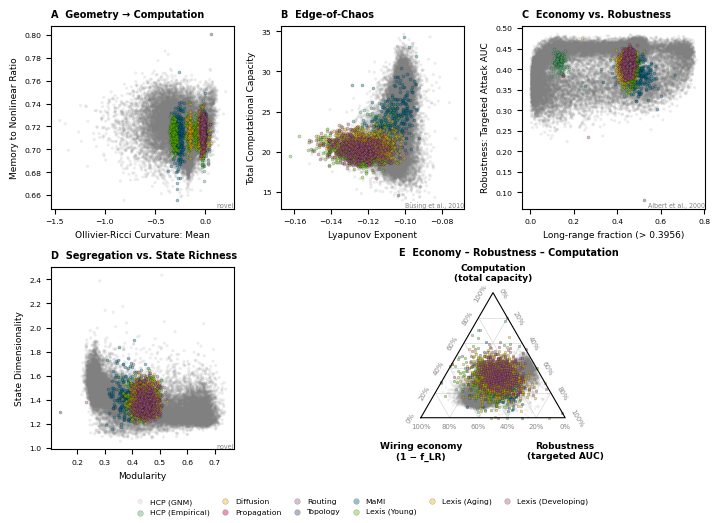

In [ ]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A A B B C C
    A A B B C C
    D D E E E E
    D D E E E E

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "ollivier_ricci_curvature_orc_mean",
        "y": "computational_capacity_memory_nonlinear_ratio",
        "title": "Geometry → Computation",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    AABBCC
    AABBCC
    DDEEEE
    DDEEEE
    """,
    figsize=viz.cm_to_inch((18, 13)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset, df_merged in dict_with_all_datasets.items():
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color="gray" if is_gnm else COLOR_SCHEME[dataset],
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset, df_merged in dict_with_all_datasets.items():
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# # ── 4. Save ──────────────────────────────────────────────────────────────────

# plt.savefig(output_folder / "trade_off_grid_novel.pdf", bbox_inches="tight", dpi=300)
# plt.savefig(output_folder / "trade_off_grid_novel.png", bbox_inches="tight", dpi=300)
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output/trade_off_scatters/trade_off_grid_novel_w_o_lexi.pdf


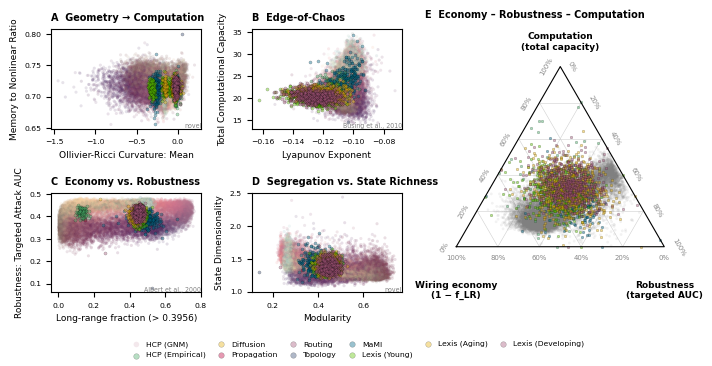

In [ ]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "ollivier_ricci_curvature_orc_mean",
        "y": "computational_capacity_memory_nonlinear_ratio",
        "title": "Geometry → Computation",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset, df_merged in dict_with_all_datasets.items():
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset, df_merged in dict_with_all_datasets.items():
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

# OLD


In [ ]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

hcp_schaefer_100_dataset_gnm
(25000,)


KeyError: 'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'

<Figure size 472.441x472.441 with 0 Axes>

In [ ]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        pass
        # plt.scatter(df["wiring_cost"], df["wiring_cost_dupa"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["avg_communicability"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:

# --- Single scatter: wiring_cost vs computational capacity ---
fig, ax = plt.subplots(figsize=(10, 7))
for dataset_name, df in dict_with_all_datasets.items():
    if "wiring_cost" in df.columns and "computational_capacity_nonlinear_capacity_total" in df.columns:
        
        if dataset_name == "hcp_schaefer_100_dataset_gnm":
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
        else:
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
            
ax.set_xlabel("Wiring Cost", fontsize=12)
ax.set_ylabel("Computational Capacity (Nonlinear Total)", fontsize=12)
ax.set_title("Wiring Cost vs. Computational Capacity", fontsize=14)
ax.legend(fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()

plt.savefig(output_folder / "scatter_wiring_vs_comp_capacity.png", dpi=200)
print(output_folder / "scatter_wiring_vs_comp_capacity.png")
plt.show()


In [ ]:
shared_numeric_cols = None
for df in dict_with_all_datasets.values():
    numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
    if shared_numeric_cols is None:
        shared_numeric_cols = numeric_cols
    else:
        shared_numeric_cols = shared_numeric_cols & numeric_cols

for col in shared_numeric_cols: 
    print(col)

# Now selected ones. 